33


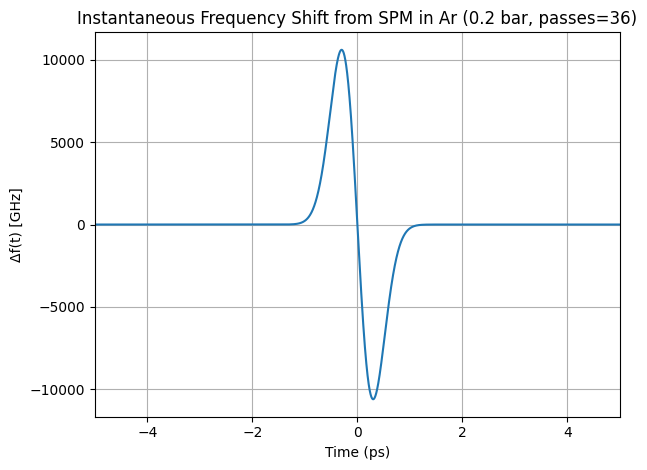

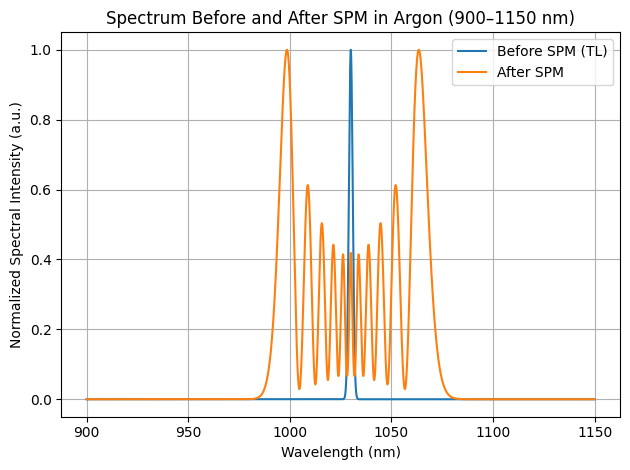

FFT ω coverage maps to roughly λ in [457, 59958492] nm.
Plotted wavelength range: [900, 1150] nm (step 0.1 nm)
Current SPM peak phase B ≈ 33.000 rad; increase pressure/passes/L/fluence to broaden more.


In [1]:
# Update: ensure spectrum axis fully covers 950–1100 nm (and more).
# We'll plot spectra on a wide 900–1150 nm range with 0.1 nm steps.
# Everything else (Argon n2, fluence->intensity, passes) remains as before.
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants as sc
from scipy.fft import fft, fftfreq, fftshift

# ----------------- User parameters -----------------
lam0_nm     = 1030.0
t_fwhm_ps   = 1.0
dlam_nm     = 0.1
lam_min_nm  = 900.0
lam_max_nm  = 1150.0

# Medium / pass parameters
L            = 10*33e-3
passes       = 36
pressure_bar = 0.160
n2_Ar_per_bar = 10e-24 #m^2/W
fluence_J_cm2 = 40.0

# Sampling
T_window_ps = 200.0
N = 2**18

# ----------------- Derived quantities -----------------
lam0   = lam0_nm * 1e-9
omega0 = 2*np.pi*sc.c/lam0
t_fwhm = t_fwhm_ps * 1e-12
sigma_t = t_fwhm/(2*np.sqrt(2*np.log(2)))
tau_sigma = sigma_t

T_window = T_window_ps * 1e-12
dt = T_window / N
t = (np.arange(N) - N//2) * dt

# Effective n2 and length; intensity from fluence
n2 = n2_Ar_per_bar * pressure_bar
L_eff = passes * L
fluence_J_m2 = fluence_J_cm2 * 1e4
I0 = fluence_J_m2 / (np.sqrt(np.pi) * tau_sigma)

# Envelope
A_t = np.exp(-(t**2)/(2*sigma_t**2))

# SPM phase
k0 = 2*np.pi/lam0
B  = k0 * n2 * L_eff * I0
B=33
print(B)
phi_spm = B * np.exp(-(t**2)/(tau_sigma**2))

# Fields
E_t_noSPM = A_t * np.exp(1j*omega0*t)
E_t_SPM   = A_t * np.exp(1j*phi_spm) * np.exp(1j*omega0*t)

# FFT -> spectrum helper on 900–1150 nm grid
lam_nm_grid = np.arange(lam_min_nm, lam_max_nm + dlam_nm, dlam_nm)
lam = lam_nm_grid * 1e-9
omega_lam = 2*np.pi*sc.c/lam

def spectrum_vs_lambda(E_t):
    f = fftshift(fftfreq(N, d=dt))
    omega = 2*np.pi * f
    E_omega = fftshift(fft(np.fft.ifftshift(E_t))) * dt
    I_omega = np.abs(E_omega)**2
    pos = omega > 0
    omega_pos = omega[pos]
    I_pos = I_omega[pos]
    I_pos /= I_pos.max() if I_pos.max()!=0 else 1.0
    sort_idx = np.argsort(omega_pos)
    I_lambda = np.interp(omega_lam, omega_pos[sort_idx], I_pos[sort_idx], left=0.0, right=0.0)
    return I_lambda, omega_pos[[0,-1]]

I_lambda_no, omega_bounds = spectrum_vs_lambda(E_t_noSPM)
I_lambda_spm, _ = spectrum_vs_lambda(E_t_SPM)

# Plots
# 1) Instantaneous frequency shift (GHz) for context
dphi_dt = np.gradient(phi_spm, dt)
delta_f_GHz = (dphi_dt/(2*np.pi)) / 1e9
plt.figure()
plt.plot(t*1e12, delta_f_GHz)
plt.xlim(-5, 5)
plt.xlabel("Time (ps)")
plt.ylabel("Δf(t) [GHz]")
plt.title(f"Instantaneous Frequency Shift from SPM in Ar ({pressure_bar:.1f} bar, passes={passes})")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2) Spectra over 900–1150 nm
plt.figure()
plt.plot(lam_nm_grid, I_lambda_no, label="Before SPM (TL)")
plt.plot(lam_nm_grid, I_lambda_spm, label="After SPM")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Spectral Intensity (a.u.)")
plt.title("Spectrum Before and After SPM in Argon (900–1150 nm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Report coverage sanity
lam_min_covered = 2*np.pi*sc.c/omega_bounds[1]*1e9
lam_max_covered = 2*np.pi*sc.c/omega_bounds[0]*1e9
print(f"FFT ω coverage maps to roughly λ in [{lam_min_covered:.0f}, {lam_max_covered:.0f}] nm.")
print("Plotted wavelength range: [%.0f, %.0f] nm (step %.1f nm)" % (lam_min_nm, lam_max_nm, dlam_nm))
print("Current SPM peak phase B ≈ %.3f rad; increase pressure/passes/L/fluence to broaden more." % B)


In [24]:
dw = 15e-3
l = 6000e-3
angle = np.arctan(dw/l)
print(angle*180/np.pi)

0.14323915036830656


In [6]:
eta2_test = 10e-24*0.16 #m^2/W
lambda0 = 1030e-9
tau_FWHM = 1.3e-12
tau = tau_FWHM/(2*np.sqrt(2*np.log(2)))
E = 100e-3
B_single = (2*np.pi)**(3/2)/lambda0**2*eta2_test*E/tau
print(B_single)

0.43025874636607175
